In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.5/95.5 kB 6.0 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO

print("YOLO imported successfully.")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
YOLO imported successfully.


In [3]:
model = YOLO("yolo11n.pt")

print("YOLO model loaded successfully.")

YOLO model loaded successfully.


In [9]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

print("Image uploaded successfully:", image_path)

Saving Screenshot 2024-09-03 223802.png to Screenshot 2024-09-03 223802 (1).png
Image uploaded successfully: Screenshot 2024-09-03 223802 (1).png


In [10]:
results = model(image_path)

print("Object detection completed successfully.")


image 1/1 /content/Screenshot 2024-09-03 223802 (1).png: 640x608 2 persons, 427.4ms
Speed: 25.0ms preprocess, 427.4ms inference, 36.1ms postprocess per image at shape (1, 3, 640, 608)
Object detection completed successfully.


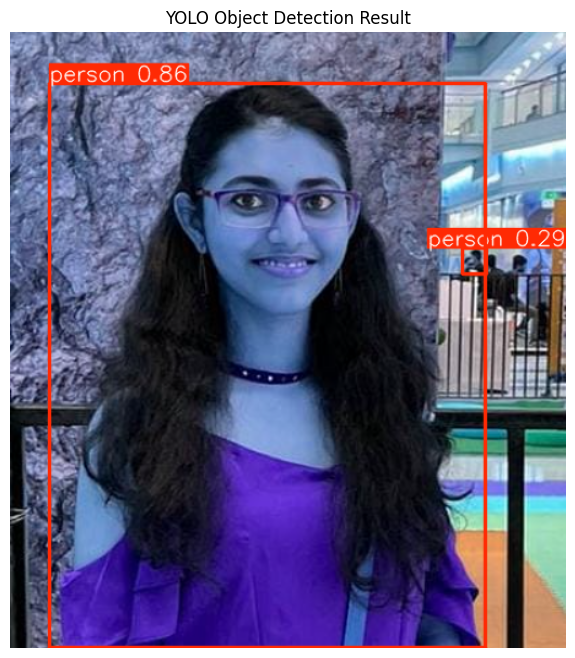

In [11]:
from PIL import Image
import matplotlib.pyplot as plt

result_image = results[0].plot()

plt.figure(figsize=(12, 8))
plt.imshow(result_image)
plt.axis("off")
plt.title("YOLO Object Detection Result")
plt.show()

In [12]:
result_image = results[0].plot()

Image.fromarray(result_image).save("YOLO_Detection_Result.jpg")

print("Detection result saved successfully.")

Detection result saved successfully.


In [13]:
for box in results[0].boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    class_name = model.names[class_id]

    print(f"{class_name}: {confidence:.2f}")

person: 0.86
person: 0.29


In [14]:
person_count = 0

for box in results[0].boxes:
    class_id = int(box.cls[0])
    class_name = model.names[class_id]

    if class_name == "person":
        person_count += 1

print("Number of persons detected:", person_count)

Number of persons detected: 2


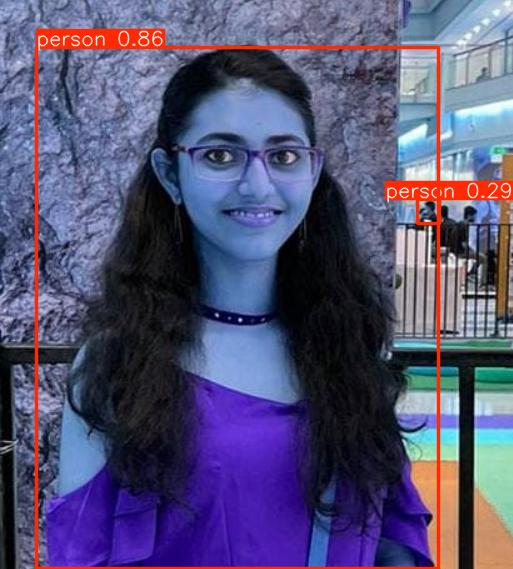

In [15]:
from IPython.display import display
from PIL import Image

final_image = Image.open("YOLO_Detection_Result.jpg")

display(final_image)